In [5]:
import torch
import math
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
import torchvision
import matplotlib.pyplot as plt
import pickle

import seaborn as sns
import pandas as pd


### Batch size

#### Signal Metrics

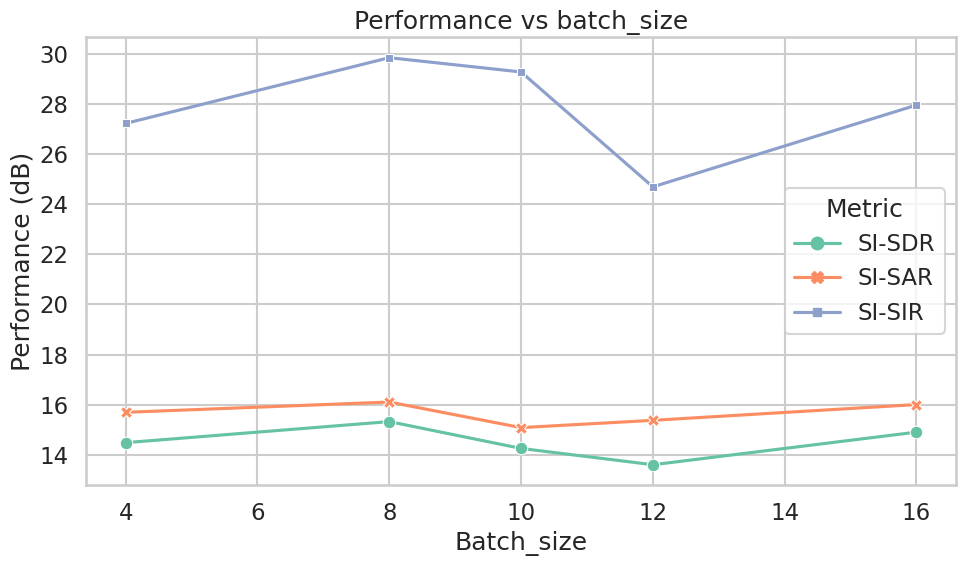

In [13]:

batch_size = [4, 8, 10, 12,  16]

si_sdr = [14.49, 15.33, 14.26, 13.61 ,14.91]
si_sir = [27.22, 29.84, 29.27, 24.69, 27.95]
si_sar = [15.7, 16.11, 15.09, 15.38, 16.01]



# Convert to long-form DataFrame
df = pd.DataFrame({
    'batch_size': [a for a in batch_size]*3,  
    'Performance ': si_sdr + si_sar + si_sir,
    'Metric': ['SI-SDR']*len(batch_size) + ['SI-SAR']*len(batch_size) + ['SI-SIR']*len(batch_size)
})

# Set seaborn style
sns.set(style="whitegrid", context="talk")

# Create lineplot
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df, 
    x='batch_size', 
    y='Performance ', 
    hue='Metric', 
    style='Metric',
    markers=True, 
    dashes=False,
    palette="Set2",
    marker='o'
)


plt.xlabel("Batch_size")
plt.ylabel("Performance (dB)")
plt.title("Performance vs batch_size")
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


### PESQ and STOI

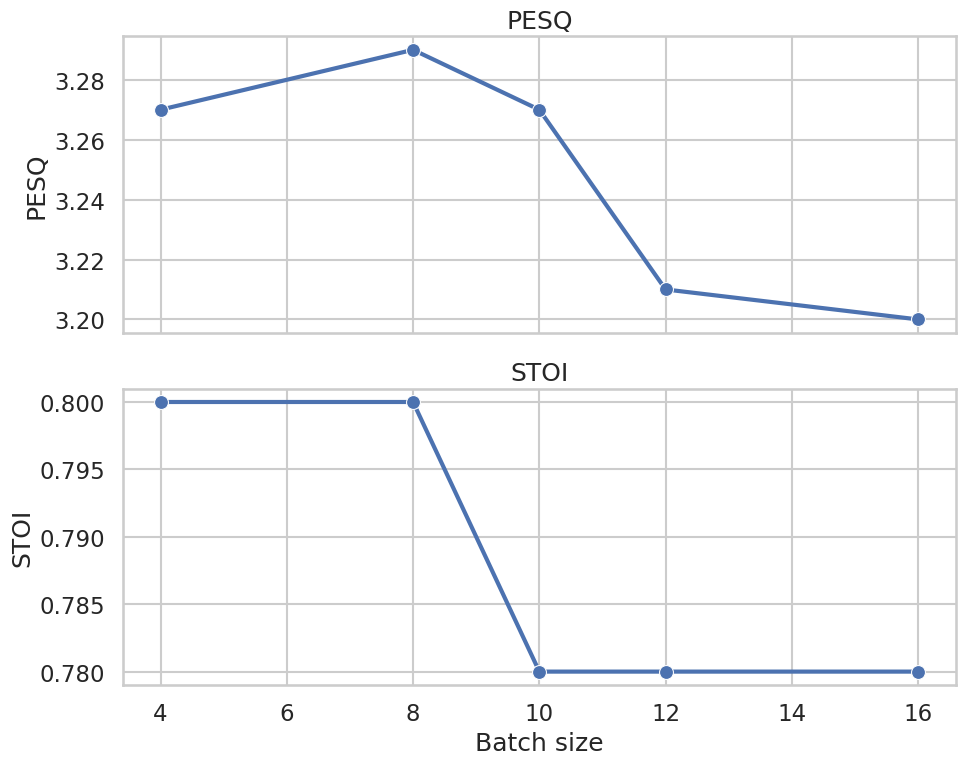

In [20]:


# Data
batch_size = [4, 8, 10, 12, 16]

stoi = [0.8, 0.8, 0.78, 0.78, 0.78]   # <-- fill
pesq = [3.27, 3.29, 3.27, 3.21, 3.2]   # <-- fill

# Build DataFrame
df = pd.DataFrame({
    'batch_size': batch_size * 2,
    'Score': pesq + stoi,
    'Metric': ['PESQ']*len(batch_size) + ['STOI']*len(batch_size)
})

# Style
sns.set(style="whitegrid", context="talk")

# Subplots
fig, axes = plt.subplots(2, 1, figsize=(10,8), sharex=True)

# PESQ
sns.lineplot(
    data=df[df["Metric"] == "PESQ"],
    x='batch_size',
    y='Score',
    marker='o',
    linewidth=3,
    ms=10,
    ax=axes[0]
)
axes[0].set_title("PESQ")
axes[0].set_xlabel("Batch size")
axes[0].set_ylabel("PESQ")

# STOI
sns.lineplot(
    data=df[df["Metric"] == "STOI"],
    x='batch_size',
    y='Score',
    marker='o',
    linewidth=3,
    ms=10,
    ax=axes[1]
)
axes[1].set_title("STOI")
axes[1].set_xlabel("Batch size")
axes[1].set_ylabel("STOI")

plt.tight_layout()
plt.show()

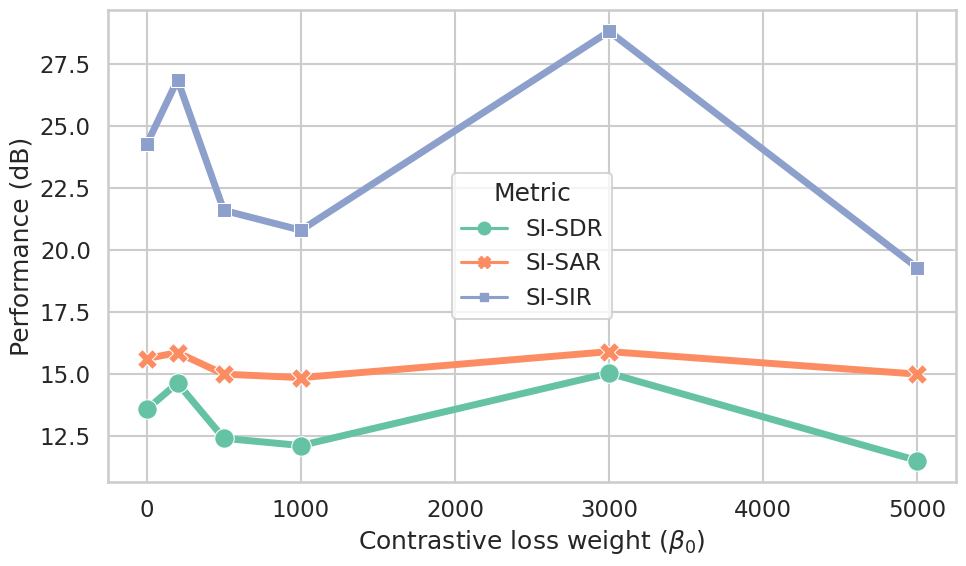

In [12]:
# Data InfoNCE
"""beta_info = [0, 50, 500, 3000, 4000, 5000, 7000, 10000]
si_sdr_info = [13.58, 14.25, 13.84, 15.33 , 11.71,14.87, 14.07, 11.29]
si_sir_info = [24.27, 27.16, 24.01, 29.84, 20.6 ,29.01 ,25.62,20.5]
si_sar_info = [15.63, 15.49, 15.43, 16.11, 14.39, 15.74 ,15.6, 13.94]"""

# Data SigLIP 
beta_sig = [0, 200, 500, 1000, 3000, 5000]
si_sdr_sig = [13.58, 14.64, 12.41 ,12.12, 15.04, 11.51]
si_sir_sig = [24.27, 26.88, 21.61 , 20.81, 28.83, 19.29]
si_sar_sig = [15.63, 15.87, 15.0, 14.86 , 15.91, 15.0]

# Convert to long-form DataFrame
df = pd.DataFrame({
    'Weight (α0)': [a for a in beta_sig]*3,  # add 1 to avoid log(0)
    'Performance (dB)': si_sdr_sig + si_sar_sig + si_sir_sig,
    'Metric': ['SI-SDR']*len(beta_sig) + ['SI-SAR']*len(beta_sig) + ['SI-SIR']*len(beta_sig)
})

# Set seaborn style
sns.set(style="whitegrid", context="talk")

# Create lineplot
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df, 
    x='Weight (α0)', 
    y='Performance (dB)', 
    hue='Metric', 
    style='Metric',
    markers=True, 
    dashes=False,
    palette="Set2",
    marker='o',
    linewidth = 5,
    ms=14,
)

#plt.xscale('log')  # log scale for x-axis
plt.xlabel(r"Contrastive loss weight ($\beta_0$)")
plt.ylabel("Performance (dB)")
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

## SigLIP vs InfoNCE

### SI-SDR, SI-SIR and SI-SAR

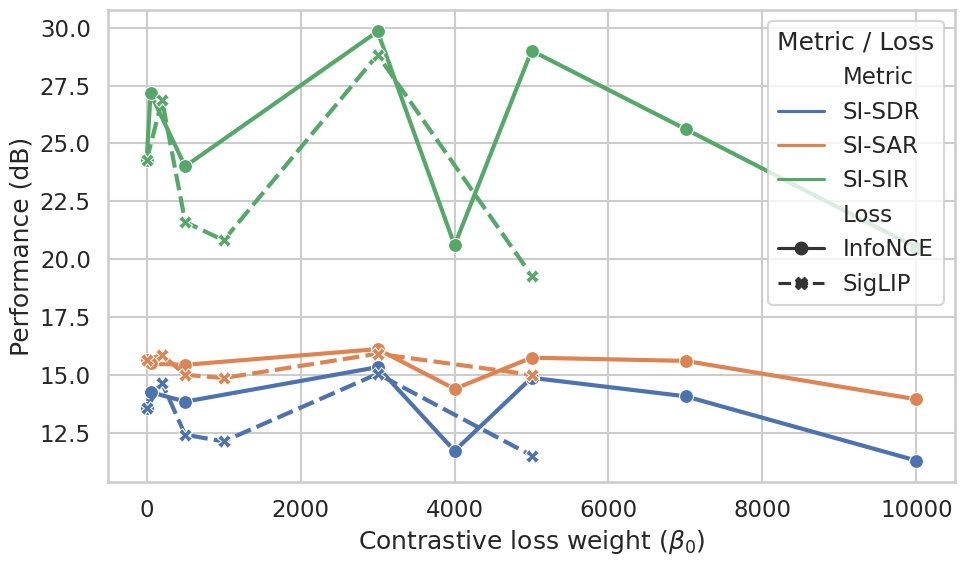

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data InfoNCE
beta_info = [0, 50, 500, 3000, 4000, 5000, 7000, 10000]
si_sdr_info = [13.58, 14.25, 13.84, 15.33 ,11.71 ,14.87, 14.07, 11.29]
si_sir_info = [24.27, 27.16 ,24.01 ,29.84 ,20.6 ,29.01 ,25.62,20.5]
si_sar_info = [15.63, 15.49 ,15.43, 16.11,14.39, 15.74 ,15.6, 13.94]

# Data SigLIP 
beta_sig = [0, 200, 500, 1000, 3000, 5000]
si_sdr_sig = [13.58, 14.64, 12.41 ,12.12, 15.04, 11.51]
si_sir_sig = [24.27, 26.88, 21.61 ,20.81, 28.83, 19.29]
si_sar_sig = [15.63, 15.87, 15.0, 14.86 ,15.91, 15.0]

# Build DataFrame
def build_df(beta, sdr, sar, sir, loss_name):
    return pd.DataFrame({
        'Weight (β0)': [b+1 for b in beta]*3,
        'Performance (dB)': sdr + sar + sir,
        'Metric': ['SI-SDR']*len(beta) + ['SI-SAR']*len(beta) + ['SI-SIR']*len(beta),
        'Loss': [loss_name]*(3*len(beta))
    })

df_info = build_df(beta_info, si_sdr_info, si_sar_info, si_sir_info, "InfoNCE")
df_sig  = build_df(beta_sig, si_sdr_sig, si_sar_sig, si_sir_sig, "SigLIP")

df = pd.concat([df_info, df_sig], ignore_index=True)

# Plot
sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(10,6))
sns.lineplot(
    data=df,
    x='Weight (β0)',
    y='Performance (dB)',
    hue='Metric',          # color = metric
    style='Loss',          # line style = loss type
    markers=True,
    dashes=True,
    linewidth=3,
    ms=10
)

plt.xlabel(r"Contrastive loss weight ($\beta_0$)")
plt.ylabel("Performance (dB)")
plt.legend(title='Metric / Loss')
plt.tight_layout()
plt.show()

### PESQ and STOI

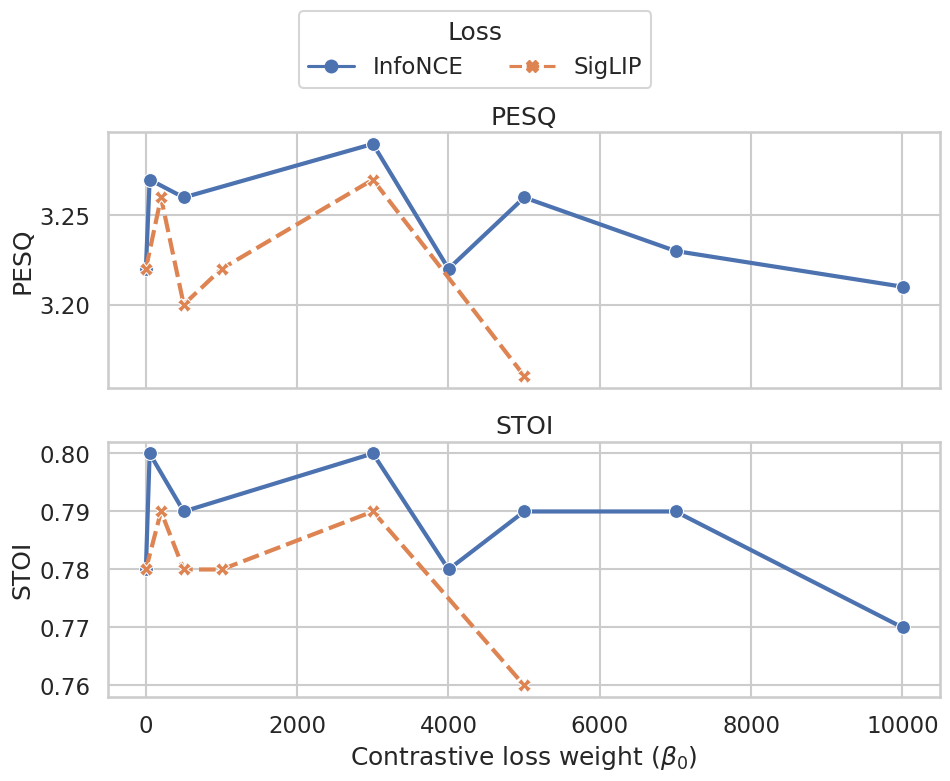

In [21]:


# -----------------------
# Data InfoNCE
# -----------------------

beta_info = [0, 50, 500, 3000, 4000, 5000, 7000, 10000]
stoi_info = [0.78, 0.8, 0.79, 0.8, 0.78, 0.79 ,0.79 ,0.77]   # <-- fill
pesq_info = [3.22  ,3.27, 3.26, 3.29, 3.22, 3.26 , 3.23, 3.21 ]  # <-- fill

# -----------------------
# Data SigLIP
# -----------------------
beta_sig = [0, 200, 500, 1000, 3000, 5000]
pesq_sig = [3.22, 3.26, 3.2, 3.22, 3.27, 3.16]    # <-- fill
stoi_sig = [0.78, 0.79, 0.78, 0.78, 0.79, 0.76]    # <-- fill

# -----------------------
# Build DataFrame
# -----------------------
def build_df(beta, pesq, stoi, loss_name):
    return pd.DataFrame({
        'Weight (β0)': [b+1 for b in beta]*2,
        'Score': pesq + stoi,
        'Metric': ['PESQ']*len(beta) + ['STOI']*len(beta),
        'Loss': [loss_name]*(2*len(beta))
    })

df_info = build_df(beta_info, pesq_info, stoi_info, "InfoNCE")
df_sig  = build_df(beta_sig, pesq_sig, stoi_sig, "SigLIP")

df = pd.concat([df_info, df_sig], ignore_index=True)

# -----------------------
# Plot
# -----------------------
sns.set(style="whitegrid", context="talk")

fig, axes = plt.subplots(2, 1, figsize=(10,8), sharex=True)

# PESQ subplot
sns.lineplot(
    data=df[df["Metric"] == "PESQ"],
    x='Weight (β0)',
    y='Score',
    hue='Loss',
    style='Loss',
    markers=True,
    dashes=True,
    linewidth=3,
    ms=10,
    ax=axes[0]
)
axes[0].set_title("PESQ")
axes[0].set_xlabel(r"Contrastive loss weight ($\beta_0$)")
axes[0].set_ylabel("PESQ")

# STOI subplot
sns.lineplot(
    data=df[df["Metric"] == "STOI"],
    x='Weight (β0)',
    y='Score',
    hue='Loss',
    style='Loss',
    markers=True,
    dashes=True,
    linewidth=3,
    ms=10,
    ax=axes[1]
)
axes[1].set_title("STOI")
axes[1].set_xlabel(r"Contrastive loss weight ($\beta_0$)")
axes[1].set_ylabel("STOI")

# Clean legend (single shared legend)
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, title="Loss")

# Remove duplicate legends
axes[0].legend().remove()
axes[1].legend().remove()

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

## SigLIP pretraining vs SigLIP without pretraining

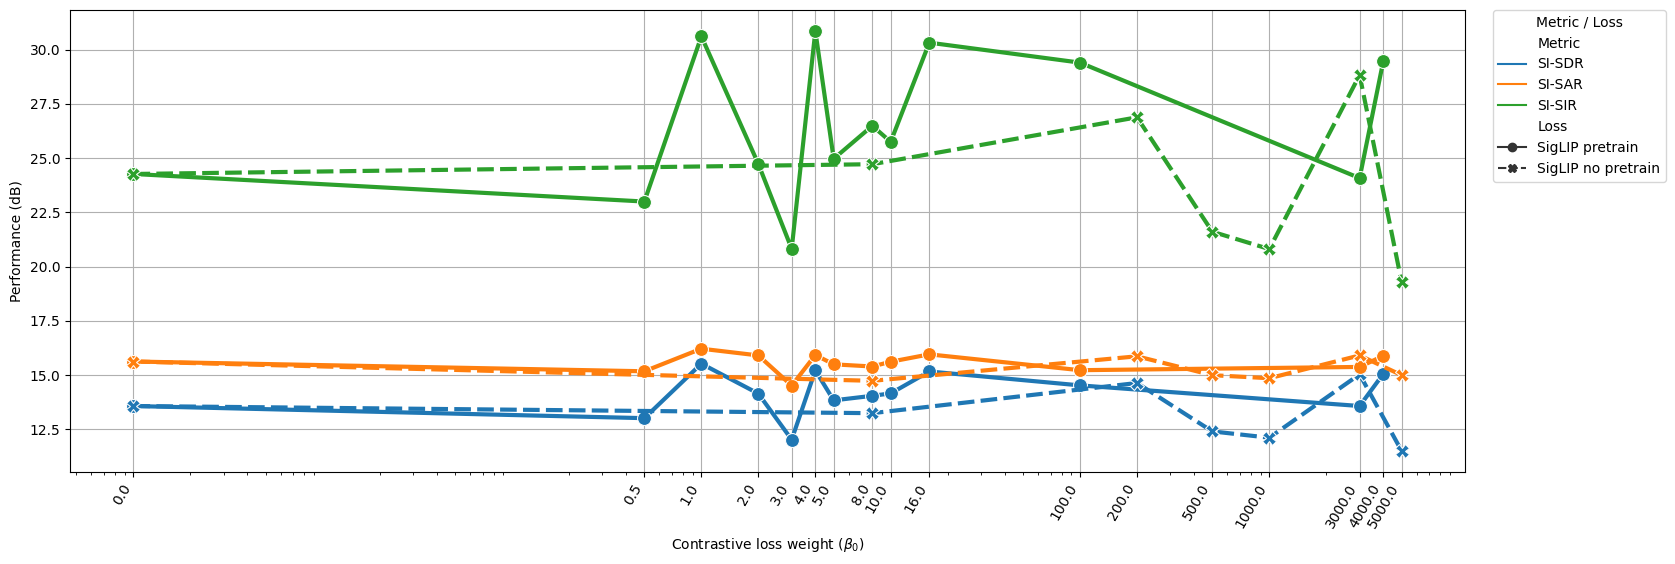

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# pretraining with SigLIP
beta_pre = [0, 0.5, 1, 2, 3, 4, 5 , 8, 10, 16 , 100, 3000, 4000]
si_sdr_pre = [13.58, 13.02, 15.53,  14.15, 12.03, 15.22, 13.84, 14.05,14.16,  15.17, 14.53, 13.58, 15.06]
si_sir_pre = [24.27, 23, 30.61, 24.73, 20.82, 30.86, 24.97, 26.49, 25.75, 30.32, 29.4 , 24.08, 29.47 ]
si_sar_pre = [15.63,15.18,16.22, 15.91, 14.52, 15.93, 15.5, 15.4 ,15.62,  15.96, 15.23, 15.38,15.89]

# Data without SigLIP  
beta_no_pre = [0, 8, 200, 500, 1000, 3000, 5000]
si_sdr_no_pre = [13.58, 13.25, 14.64, 12.41, 12.12, 15.04, 11.51]
si_sir_no_pre = [24.27, 24.72, 26.88, 21.61, 20.81, 28.83, 19.29]
si_sar_no_pre = [15.63, 14.74, 15.87, 15, 14.86, 15.91, 15]

# Build DataFrame
def build_df(beta, sdr, sar, sir, loss_name):
    return pd.DataFrame({
        'Weight (β0)': [b for b in beta]*3,
        'Performance (dB)': sdr + sar + sir,
        'Metric': ['SI-SDR']*len(beta) + ['SI-SAR']*len(beta) + ['SI-SIR']*len(beta),
        'Loss': [loss_name]*(3*len(beta))
    })

df_info = build_df(beta_pre, si_sdr_pre, si_sar_pre, si_sir_pre, "SigLIP pretrain")
df_sig  = build_df(beta_no_pre, si_sdr_no_pre, si_sar_no_pre, si_sir_no_pre, "SigLIP no pretrain")

df = pd.concat([df_info, df_sig], ignore_index=True)

# Plot
df['Weight_plot'] = df['Weight (β0)'].replace(0, 1e-3)

plt.figure(figsize=(18,6))

ax = sns.lineplot(
    data=df,
    x='Weight_plot',
    y='Performance (dB)',
    hue='Metric',
    style='Loss',
    markers=True,
    dashes=True,
    linewidth=3,
    ms=10
)

ax.set_xscale('log')

all_betas = sorted(df['Weight (β0)'].unique())

ax.set_xticks([b if b > 0 else 1e-3 for b in all_betas])
ax.set_xticklabels([str(b) for b in all_betas], rotation=60, ha='right')

plt.xlabel(r"Contrastive loss weight ($\beta_0$)")
plt.ylabel("Performance (dB)")

plt.legend(
    title='Metric / Loss',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)
plt.grid() 
#plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()

### PESQ and STOI

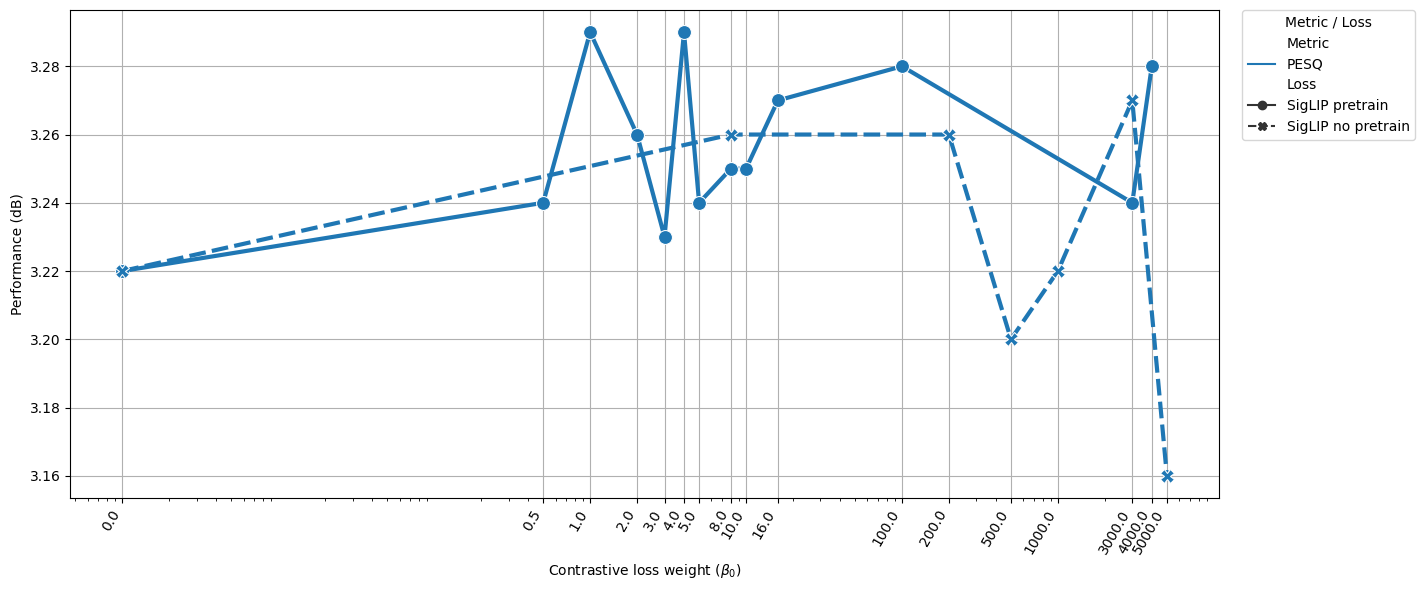

In [16]:
# pretraining with SigLIP
beta_pre = [0, 0.5, 1, 2, 3, 4, 5 , 8, 10, 16 , 100, 3000, 4000]
pesq_pre = [3.22, 3.24, 3.29, 3.26, 3.23,3.29,3.24,3.25,3.25, 3.27,3.28,3.24,3.28]
stoi_pre = []#0.78,0.79, 0.8 , 0.8, 0.78, 0.8, 0.79, 0.79, 0.79, 0.79, 0.8, 0.79, 0.79]



# Data without SigLIP  
beta_no_pre = [0,8, 200, 500, 1000, 3000, 5000]
pesq_no_pre = [3.22, 3.26,  3.26, 3.2, 3.22, 3.27, 3.16 ]
stoi_no_pre = []#0.78, 0.79,0.79, 0.78, 0.78, 0.79, 0.76]


# Build DataFrame
def build_df(beta, pesq, stoi, loss_name):
    return pd.DataFrame({
        'Weight (β0)': [b for b in beta]*1,
        'Performance (dB)': pesq ,#+ stoi,
        'Metric': ['PESQ']*len(beta),# + ['STOI']*len(beta),
        'Loss': [loss_name]*(1*len(beta))
    })

df_info = build_df(beta_pre, pesq_pre, stoi_pre, "SigLIP pretrain")
df_sig  = build_df(beta_no_pre, pesq_no_pre, stoi_no_pre, "SigLIP no pretrain")

df = pd.concat([df_info, df_sig], ignore_index=True)

# Plot
df['Weight_plot'] = df['Weight (β0)'].replace(0, 1e-3)

plt.figure(figsize=(18,6))

ax = sns.lineplot(
    data=df,
    x='Weight_plot',
    y='Performance (dB)',
    hue='Metric',
    style='Loss',
    markers=True,
    dashes=True,
    linewidth=3,
    ms=10
)

ax.set_xscale('log')

all_betas = sorted(df['Weight (β0)'].unique())

ax.set_xticks([b if b > 0 else 1e-3 for b in all_betas])
ax.set_xticklabels([str(b) for b in all_betas], rotation=60, ha='right')

plt.xlabel(r"Contrastive loss weight ($\beta_0$)")
plt.ylabel("Performance (dB)")

plt.legend(
    title='Metric / Loss',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)
plt.grid() 
plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()